In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [4]:
from os import read
from google.colab import drive
drive.mount('/content/drive')

df = "/content/drive/MyDrive/Colab Notebooks/Initial_Modeling_Dataset.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
df_data = pd.read_csv(df)
y = df_data["attrition_flag"]
X = df_data.drop(columns=["attrition_flag"])

In [7]:
X = pd.get_dummies(X, drop_first=True)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)

model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000)

In [11]:
y_pred = model.predict(X_test_scaled)

In [12]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.812

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      2294
           1       0.57      0.79      0.67       706

    accuracy                           0.81      3000
   macro avg       0.75      0.81      0.77      3000
weighted avg       0.84      0.81      0.82      3000


Confusion Matrix:
[[1876  418]
 [ 146  560]]


In [13]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

print(coefficients.head(10))   # Top drivers of staying
print(coefficients.tail(10))   # Top drivers of leaving

                  Feature  Coefficient
10  low_satisfaction_flag     1.117926
9         high_hours_flag     0.387069
25        tenure_band_3-5     0.381798
7            tenure_years     0.372849
4      time_spend_company     0.372849
1         last_evaluation     0.290920
22             salary_low     0.223751
14          department_hr     0.066035
20   department_technical     0.057437
3    average_montly_hours     0.042465
                  Feature  Coefficient
11          department_IT    -0.048031
15  department_management    -0.088576
12       department_RandD    -0.141434
6   promotion_last_5years    -0.153632
8       early_tenure_flag    -0.241672
24        tenure_band_0-2    -0.241672
26       tenure_band_6-10    -0.271641
21            salary_high    -0.372999
2          number_project    -0.416982
5           work_accident    -0.507155


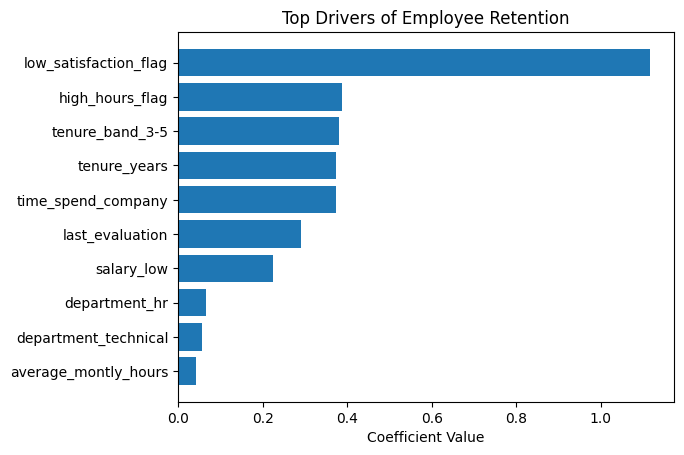

In [15]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

# Top 10 features
top_features = coefficients.head(10)

plt.figure()
plt.barh(top_features["Feature"], top_features["Coefficient"])

plt.xlabel("Coefficient Value")
plt.title("Top Drivers of Employee Retention")

plt.gca().invert_yaxis()

plt.show()

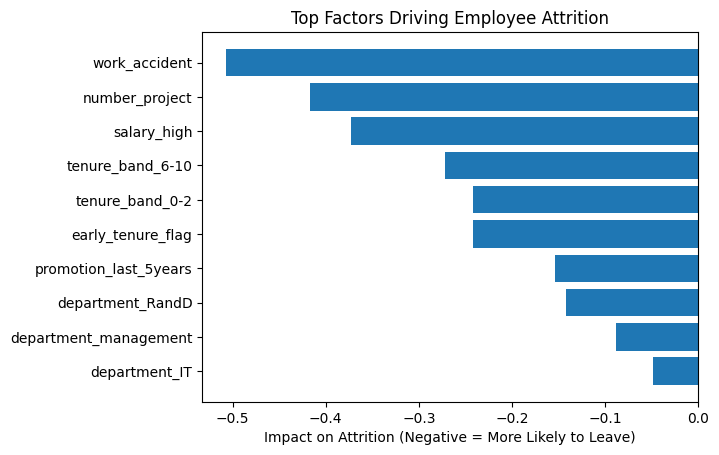

In [16]:
# Create dataframe of coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

# Sort ascending → most negative = strongest drivers of leaving
coefficients = coefficients.sort_values(by="Coefficient")

# Select top 10 drivers of leaving
top_leaving = coefficients.head(10)

# Plot
import matplotlib.pyplot as plt

plt.figure()
plt.barh(top_leaving["Feature"], top_leaving["Coefficient"])

plt.xlabel("Impact on Attrition (Negative = More Likely to Leave)")
plt.title("Top Factors Driving Employee Attrition")

plt.gca().invert_yaxis()

plt.show()

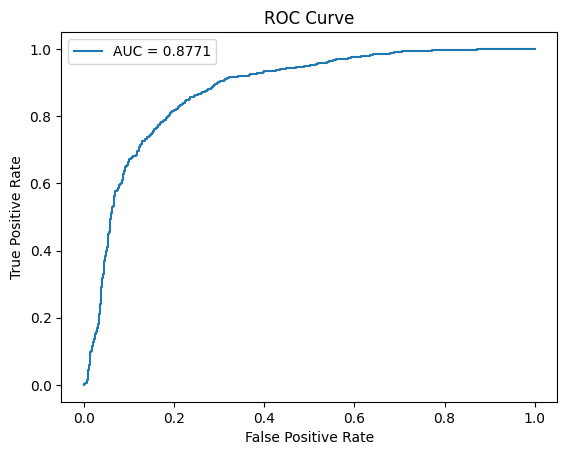

In [17]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {round(roc_auc,4)}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()